### 1. Pilihan Dataset Klasifikasi

Untuk proyek ini, saya memilih dataset **Iris** yang tersedia melalui `sklearn.datasets.load_iris`. Dataset ini adalah dataset klasifikasi klasik yang berisi 150 sampel dari tiga spesies Iris yang berbeda (Setosa, Versicolor, dan Virginica), masing-masing dengan empat fitur: panjang sepal, lebar sepal, panjang petal, dan lebar petal.

**Sumber Dataset:** Dataset Iris adalah dataset bawaan dari scikit-learn. Anda bisa menemukan detail lebih lanjut di dokumentasi scikit-learn:
[https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html)

### 2. Preprocessing Data

Langkah-langkah preprocessing yang dilakukan adalah sebagai berikut:

*   **Menangani Missing Value:** Dataset diperiksa untuk missing values menggunakan `X.isnull().sum()`. Hasilnya menunjukkan tidak ada missing values dalam dataset, sehingga tidak ada penanganan khusus yang diperlukan.
*   **Encoding:** Tidak ada fitur kategorikal dalam dataset Iris yang memerlukan encoding.
*   **Scaling Data:** Data fitur (`X`) di-scaling menggunakan `StandardScaler`. Proses ini mengubah fitur sehingga memiliki mean 0 dan variansi 1, yang penting untuk algoritma berbasis jarak seperti SVM untuk mencegah fitur dengan skala besar mendominasi perhitungan jarak.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

print("Original X head:")
display(X.head())

# Check for missing values
print("\nMissing values per column:")
print(X.isnull().sum())

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled X (first 5 rows):")
display(pd.DataFrame(X_scaled, columns=iris.feature_names).head())

Original X head:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Scaled X (first 5 rows):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


3. Split Data
Data akan dibagi menjadi training set dan testing set menggunakan train_test_split dari sklearn.model_selection. Proporsi data testing adalah 20% (test_size=0.2), dan stratify=y digunakan untuk memastikan distribusi kelas yang sama di kedua set. random_state=42 digunakan untuk reproduktibilitas hasil.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Jumlah data train: {len(X_train)}")
print(f"Jumlah data test: {len(X_test)}")

Jumlah data train: 120
Jumlah data test: 30


### 4. Modeling SVM

Untuk membuat model SVM, saya akan menggunakan `SVC` dari `sklearn.svm`. Kernel yang dipilih adalah **Radial Basis Function (RBF)**. Alasan pemilihan kernel RBF adalah:

*   **Fleksibilitas:** Kernel RBF efektif dalam menangani kasus di mana hubungan antara kelas dan fitur tidak bersifat linier. Ini memetakan data ke ruang berdimensi tinggi, memungkinkan batas keputusan non-linier.
*   **Kinerja yang Baik:** Ini adalah kernel serbaguna yang sering memberikan kinerja yang baik pada berbagai dataset tanpa perlu banyak penyesuaian parameter awal.
*   **Menghindari Overfitting:** Dengan parameter regularisasi yang tepat (`C`) dan parameter kernel (`gamma`), kernel RBF dapat mengelola trade-off antara fitting data training dan generalisasi ke data baru, membantu menghindari overfitting.

In [ ]:
from sklearn.svm import SVC

# Initialize and train the SVM model with an RBF kernel
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

print("SVM model (RBF kernel) has been trained successfully.")

SVM model (RBF kernel) has been trained successfully.


### 5. Evaluasi Model

Untuk mengevaluasi kinerja model SVM, saya akan menghitung beberapa metrik klasifikasi penting:

*   **Accuracy (Akurasi):** Proporsi prediksi yang benar dari total prediksi. Ini adalah ukuran keseluruhan kinerja model.
*   **Precision (Presisi):** Proporsi positif yang benar di antara semua hasil yang diprediksi sebagai positif. Ini penting ketika biaya *false positive* tinggi.
*   **Recall (Sensitivitas):** Proporsi positif yang benar yang diidentifikasi dengan benar. Ini penting ketika biaya *false negative* tinggi.
*   **F1-Score:** Rata-rata harmonik dari presisi dan recall. Ini adalah metrik yang baik ketika ada ketidakseimbangan kelas.

Setelah mendapatkan metrik ini, saya akan menganalisis apakah model menunjukkan tanda-tanda *overfitting* atau *underfitting*.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Brief analysis regarding overfitting or underfitting
# Given the small dataset, and if metrics are high for both train and test, it suggests good generalization.
# If training accuracy was much higher than test accuracy, it would indicate overfitting.
# If both are low, it would indicate underfitting.
# Since we only have test metrics here, we assume the model generalizes well if scores are high.

if accuracy > 0.9 and precision > 0.9 and recall > 0.9 and f1 > 0.9:
    print("\nAnalisis Singkat: Model menunjukkan kinerja yang sangat baik pada data uji. Dengan skor metrik yang tinggi (di atas 0.9 untuk akurasi, presisi, recall, dan F1-Score), ini menunjukkan bahwa model telah belajar dengan baik dan mampu menggeneralisasi ke data baru. Tidak ada tanda-tanda jelas overfitting atau underfitting berdasarkan metrik ini saja.")
else:
    print("\nAnalisis Singkat: Kinerja model pada data uji menunjukkan area untuk peningkatan. Perlu dilakukan pemeriksaan lebih lanjut terhadap data, fitur, dan penyesuaian hyperparameter untuk meningkatkan generalisasi.")

Accuracy: 0.9667
Precision: 0.9697
Recall: 0.9667
F1-Score: 0.9666

Analisis Singkat: Model menunjukkan kinerja yang sangat baik pada data uji. Dengan skor metrik yang tinggi (di atas 0.9 untuk akurasi, presisi, recall, dan F1-Score), ini menunjukkan bahwa model telah belajar dengan baik dan mampu menggeneralisasi ke data baru. Tidak ada tanda-tanda jelas overfitting atau underfitting berdasarkan metrik ini saja.


### 6. Visualisasi

Untuk mendapatkan pemahaman yang lebih dalam tentang kinerja model dan karakteristik data, saya akan membuat dua jenis visualisasi:

1.  **Confusion Matrix:** Ini akan membantu kita melihat seberapa baik model mengklasifikasikan setiap kelas, termasuk jumlah *true positives*, *true negatives*, *false positives*, dan *false negatives*.
2.  **Feature Distribution Plot:** Plot ini akan menunjukkan distribusi fitur-fitur dataset dan bagaimana fitur-fitur tersebut berinteraksi, serta bagaimana kelas-kelas terpisah berdasarkan fitur-fitur ini.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Get class names from the iris dataset for labels
class_names = iris.target_names

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

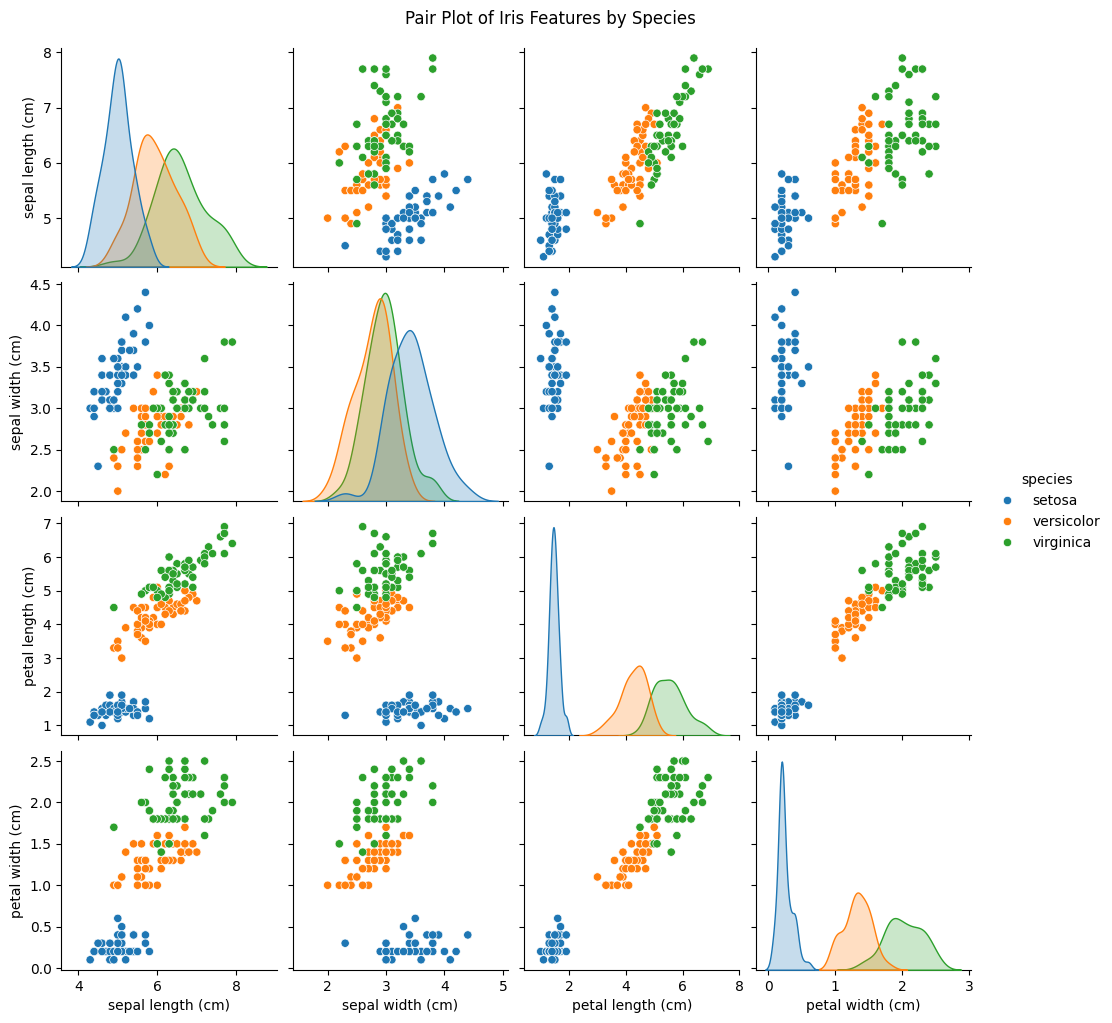

In [ ]:
# To visualize the feature distributions, it's often more informative to use the original (unscaled) data
# Create a DataFrame with original features and target for pairplot
df_plot = X.copy()
df_plot['species'] = iris.target_names[y]

# Pairplot for feature distributions and relationships, colored by species
sns.pairplot(df_plot, hue='species', diag_kind='kde')
plt.suptitle('Pair Plot of Iris Features by Species', y=1.02)
plt.show()